[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ofermend/hands-on-rag/blob/main/chapter2/parse-pdf.ipynb)

# Chapter 2: Parsing PDF Documents

This notebook demonstrates PDF text extraction using PyMuPDF, including handling text, images, and document structure.

**What you'll learn:**
- Extract text from PDFs at page and block level using PyMuPDF
- Parse and extract table contents from PDF pages
- Separate unstructured text from tabular data
- Extract embedded images from PDF documents

**Prerequisites:** `pip install PyMuPDF pandas Pillow`

## Setup

We load PyMuPDF and supporting libraries for parsing PDF text, tables, and images.

In [4]:
import json
import pymupdf
import pandas as pd
from IPython.display import Image, display
import io

In [14]:

# pymupdf.open(): Reads from Hard Disk to C RAM
# doc: holds a memory address (a pointer) pointing directly to the location in the C RAM where MuPDF is holding the file.
doc = pymupdf.open("sample_data/sample_data.pdf")

# Extract all text on one page
for i in range(doc.page_count):
    page = doc[i]          # same as doc.load_page(i)
    # extract text from MuPDF's C page object and copy it into a Python string.
    text: str = page.get_text()
    print(text, end="---")
  
# Close the document after the loop finishes
doc.close()

Sample doc for RAG Book chapter 2
This is a great chapter 
Revision
Year
0.0.1
2025
Book
Revision
Year
Author
Memory and RAG
0.1.0
2026
A great researcher
RAG and AI
0.0.1
2025
---

## Extract Text Blocks

Block-level extraction preserves the spatial layout of the PDF, returning each text region separately so you can distinguish headings, paragraphs, and table areas.

In [ ]:
# pymupdf.open(): opens the file and parses its structure into MuPDF's C memory
# doc: a Python object that holds a pointer to MuPDF's C document object
doc = pymupdf.open("sample_data/sample_data.pdf")

# Extract text in blocks
for i in range(doc.page_count):
    page = doc[i]          # same as doc.load_page(i)
    # extract text blocks from MuPDF's C page object into a Python list of tuples
    blocks: list[tuple] = page.get_text("blocks")
    for block in blocks:
        # block = (x0, y0, x1, y1, text, block_no, block_type)
        print(block[4], end="---\n")

# Close the document after the loop finishes
doc.close()

'''
The text sits at position 4, so block[4] pulls it out of the tuple. The other elements of the tuple are:
block[0] to block[3] are the rectangle around the block on the page. (x0, y0) is the top left corner and (x1, y1) is the bottom right, measured in points from the top left of the page.

block[5] is the block's number on the page, starting at 0.

block[6] is the block type: 0 means text, 1 means image.
'''

'''
page.get_text("text")      # plain string (the default)
page.get_text("blocks")    # list of (x0, y0, x1, y1, text, block_no, block_type)
page.get_text("words")     # list of (x0, y0, x1, y1, word, block_no, line_no, word_no)
page.get_text("dict")      # nested dict: blocks > lines > spans, with fonts and sizes
page.get_text("rawdict")   # like "dict", but broken down to single characters
page.get_text("html")   
'''

Sample doc for RAG Book chapter 2
---
This is a great chapter 
---
Revision
Year
0.0.1
2025
---
Book
Revision
Year
Author
Memory and RAG
0.1.0
2026
A great researcher
RAG and AI
0.0.1
2025
---


'\npage.get_text("text")      # plain string (the default)\npage.get_text("blocks")    # list of (x0, y0, x1, y1, text, block_no, block_type)\npage.get_text("words")     # list of (x0, y0, x1, y1, word, block_no, line_no, word_no)\npage.get_text("dict")      # nested dict: blocks > lines > spans, with fonts and sizes\npage.get_text("rawdict")   # like "dict", but broken down to single characters\npage.get_text("html")   \n'

## Extract Table Contents

PyMuPDF can detect table boundaries on each page and return cell contents as nested lists, giving you structured data without manual parsing.

In [1]:
from pathlib import Path

import pymupdf

PDF_FILE_PATH: Path = Path("sample_data/sample_data.pdf")
# pymupdf.open(): opens the file and parses its structure into MuPDF's C memory
# doc: a Python object that holds a pointer to MuPDF's C document object
document: pymupdf.Document = pymupdf.open(PDF_FILE_PATH)

# try/finally makes sure close() runs even if table extraction raises an error.
try:
    page_count: int = document.page_count

    for page_index in range(page_count):
        page: pymupdf.Page = document[page_index]
        page_number: int = page_index + 1
        
        # tables.tables: the plain Python list of Table objects inside the TableFinder
        table_finder: pymupdf.table.TableFinder = page.find_tables()
        tables_on_page: list[pymupdf.table.Table] = table_finder.tables
        table_count: int = len(tables_on_page)

        for table_index in range(table_count):
            table: pymupdf.table.Table = tables_on_page[table_index]
            table_number: int = table_index + 1

            # A cell is None when the table has no text at that position,
            # such as the covered part of a merged cell.
            # extract(): copies the table's cells into a Python list of rows
            table_rows: list[list[str | None]] = table.extract()

            print(f"Page {page_number}, Table {table_number}")
            print(table_rows)
            print()
finally:
    # Close the document after the loop finishes
    document.close()

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
Page 1, Table 1
[['Revision', 'Year'], ['0.0.1', '2025']]

Page 1, Table 2
[['Book', 'Revision', 'Year', 'Author'], ['Memory and RAG', '0.1.0', '2026', 'A great researcher'], ['RAG and AI', '0.0.1', '2025', None]]



## Full Extraction with Unstructured

To feed clean paragraph text into a RAG pipeline, we need to filter out table content — this function uses bounding-box clipping to separate unstructured text from tabular data.

In [2]:
from pathlib import Path
from typing import Any, Final

import pymupdf

# PyMuPDF returns the "dict" extraction result as nested plain dicts and lists
# with no published type definitions, so values read from it are typed as Any.
TextDictionary = dict[str, Any]

DICT_EXTRACTION_MODE: Final[str] = "dict"
TEXT_BLOCK_TYPE: Final[int] = 0
LINE_SEPARATOR: Final[str] = "\n"
PAGE_SEPARATOR: Final[str] = "\n\n"
SAMPLE_PDF_PATH: Final[Path] = Path("sample_data/sample_data.pdf")


def collect_table_rectangles(page: pymupdf.Page) -> list[pymupdf.Rect]:
    """
    Return the bounding rectangle of every table detected on the page.
    """
    table_rectangles: list[pymupdf.Rect] = []

    table_finder = page.find_tables()
    detected_tables = table_finder.tables

    for table in detected_tables:
        table_rectangle = pymupdf.Rect(table.bbox)
        table_rectangles.append(table_rectangle)

    return table_rectangles


def build_line_text(line_dictionary: TextDictionary) -> str:
    """
    Join the text of every span in a line, matching how "text" mode builds a line.
    """
    line_spans = line_dictionary["spans"]
    span_texts: list[str] = []

    for span in line_spans:
        span_text = span["text"]
        span_texts.append(span_text)

    line_text = "".join(span_texts)

    return line_text


def get_line_center_point(line_dictionary: TextDictionary) -> pymupdf.Point:
    """
    Return the center point of a line's bounding box.
    """
    line_rectangle = pymupdf.Rect(line_dictionary["bbox"])

    center_x = (line_rectangle.x0 + line_rectangle.x1) / 2
    center_y = (line_rectangle.y0 + line_rectangle.y1) / 2

    line_center_point = pymupdf.Point(center_x, center_y)

    return line_center_point


def is_point_inside_any_table(
    point: pymupdf.Point,
    table_rectangles: list[pymupdf.Rect],
) -> bool:
    """
    Return True when the point lies inside any table rectangle.

    The line's center point is used instead of its full box so that a heading
    sitting just above a table, whose box slightly overlaps the table border,
    is not mistaken for table content.
    """
    for table_rectangle in table_rectangles:
        if table_rectangle.contains(point):
            return True

    return False


def extract_non_table_lines(page: pymupdf.Page) -> list[str]:
    """
    Return the non-empty, stripped lines on the page that are not inside a table.
    """
    table_rectangles = collect_table_rectangles(page)

    page_dictionary = page.get_text(DICT_EXTRACTION_MODE)
    page_blocks = page_dictionary["blocks"]

    non_table_lines: list[str] = []

    for block in page_blocks:
        block_type = block["type"]

        # Image blocks have no "lines" key and contain no text.
        if block_type != TEXT_BLOCK_TYPE:
            continue

        block_lines = block["lines"]

        for line_dictionary in block_lines:
            raw_line_text = build_line_text(line_dictionary)
            stripped_line_text = raw_line_text.strip()

            if stripped_line_text == "":
                continue

            line_center_point = get_line_center_point(line_dictionary)
            line_is_inside_table = is_point_inside_any_table(
                line_center_point,
                table_rectangles,
            )

            if line_is_inside_table:
                continue

            non_table_lines.append(stripped_line_text)

    return non_table_lines


def extract_unstructured_text(pdf_path: str | Path) -> str:
    """
    Extract paragraph text from a PDF, excluding text that lies inside tables.

    Lines on a page are joined with a newline. Pages are joined with a blank
    line. Pages with no remaining text are skipped.

    Raises:
        FileNotFoundError: if no file exists at pdf_path.
        pymupdf.FileDataError: if the file is not a readable PDF.
    """
    pdf_file_path = Path(pdf_path)

    if not pdf_file_path.is_file():
        raise FileNotFoundError(f"PDF file not found: {pdf_file_path}")

    page_texts: list[str] = []

    document = pymupdf.open(pdf_file_path)

    # The document is closed in `finally` so the file handle is released
    # even if extraction fails partway through a page.
    try:
        document_pages = document.pages()

        for page in document_pages:
            non_table_lines = extract_non_table_lines(page)

            if len(non_table_lines) == 0:
                continue

            page_unstructured_text = LINE_SEPARATOR.join(non_table_lines)
            page_texts.append(page_unstructured_text)
    finally:
        document.close()

    unstructured_text = PAGE_SEPARATOR.join(page_texts)

    return unstructured_text


if __name__ == "__main__":
    unstructured_content = extract_unstructured_text(SAMPLE_PDF_PATH)
    print("Unstructured text extracted:")
    print(unstructured_content)

Unstructured text extracted:
Sample doc for RAG Book chapter 2
This is a great chapter


## Extract Images

PDFs often embed raster images that carry information not present in the text — here we extract and display each image found on every page.

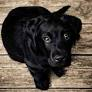

In [1]:

from dataclasses import dataclass
from pathlib import Path
from typing import Final

import pymupdf
from IPython.display import Image as NotebookImage
from IPython.display import display

SAMPLE_PDF_PATH: Final[Path] = Path("sample_data/sample_data.pdf")
IMAGE_OUTPUT_DIRECTORY: Final[Path] = Path(".")

# Page.get_images() returns one tuple per image: (xref, smask, width, ...).
IMAGE_XREF_POSITION: Final[int] = 0

IMAGE_BYTES_KEY: Final[str] = "image"
IMAGE_EXTENSION_KEY: Final[str] = "ext"


@dataclass(frozen=True)
class ExtractedImage:
    image_bytes: bytes
    image_extension: str


def extract_image_from_document(
    document: pymupdf.Document,
    image_xref: int,
) -> ExtractedImage:
    """
    Read the raw bytes and file extension of one embedded image.

    Raises:
        ValueError: if PyMuPDF returns None, which it does when the xref is
            out of range or does not point to an image.
    """
    extracted_image_dictionary = document.extract_image(image_xref)

    if extracted_image_dictionary is None:
        raise ValueError(
            f"Object with xref {image_xref} could not be extracted as an image."
        )

    image_bytes = extracted_image_dictionary[IMAGE_BYTES_KEY]
    image_extension = extracted_image_dictionary[IMAGE_EXTENSION_KEY]

    extracted_image = ExtractedImage(
        image_bytes=image_bytes,
        image_extension=image_extension,
    )

    return extracted_image


def build_image_output_path(
    output_directory: Path,
    page_number: int,
    image_index: int,
    image_extension: str,
) -> Path:
    """
    Build the file path for one extracted image.

    page_number is zero-based, as PyMuPDF reports it.
    """
    image_file_name = f"extracted_image_{page_number}_{image_index}.{image_extension}"
    image_output_path = output_directory / image_file_name

    return image_output_path


def display_and_save_pdf_images(
    pdf_path: Path,
    output_directory: Path,
) -> None:
    """
    Display every embedded image of the PDF in the notebook and save it to disk.

    Side effects:
        - Renders each image in the Jupyter output cell.
        - Writes one file per image into output_directory, overwriting any
          existing file with the same name.

    Raises:
        FileNotFoundError: if no file exists at pdf_path.
        ValueError: if an image listed on a page cannot be extracted.
    """
    if not pdf_path.is_file():
        raise FileNotFoundError(f"PDF file not found: {pdf_path}")

    document = pymupdf.open(pdf_path)

    # The document is closed in `finally` so the file handle is released
    # even if extraction fails partway through.
    try:
        document_pages = document.pages()

        for page in document_pages:
            page_number = page.number
            page_image_list = page.get_images(full=False)

            for image_index, image_info in enumerate(page_image_list):
                image_xref = image_info[IMAGE_XREF_POSITION]

                extracted_image = extract_image_from_document(document, image_xref)

                notebook_image = NotebookImage(data=extracted_image.image_bytes)
                display(notebook_image)

                image_output_path = build_image_output_path(
                    output_directory,
                    page_number,
                    image_index,
                    extracted_image.image_extension,
                )
                image_output_path.write_bytes(extracted_image.image_bytes)
    finally:
        document.close()


if __name__ == "__main__":
    display_and_save_pdf_images(SAMPLE_PDF_PATH, IMAGE_OUTPUT_DIRECTORY)